In [1]:
from pydantic import BaseModel, Field
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from operator import add
from typing import Any, Annotated, Dict, List

from langchain_core.messages import BaseMessage, AIMessage, ToolMessage, HumanMessage, SystemMessage
from langchain_core.tools import BaseTool
from langchain_core.prompts import BasePromptTemplate
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.prompts import StringPromptTemplate
from langchain_core.prompts import PromptTemplate
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import convert_to_openai_messages, convert_to_messages
from langchain_protocol import Literal

from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance, PayloadSchemaType, PointStruct, SparseVectorParams, Document,Prefetch, FusionQuery
from qdrant_client import models

import instructor
from langsmith import traceable, get_current_run_tree

import pandas as pd
import openai
import fastembed

from jinja2 import Template
from typing import List, Dict, Any, Optional, Union
from IPython.display import Image, display
from operator import add
from openai import OpenAI

import random
import ast
import inspect
import instructor
import json
import os
import importlib
import utils
from dotenv import load_dotenv

load_dotenv()
importlib.reload(utils)

from utils import format_ai_message, parse_function_definition, get_type_from_annotation, parse_docstring_params, get_tool_descriptions

/Users/kishorkumarparoi/Desktop/Maven - The AI Engineering Bootcamp /Resources/AIE5-main/24_Langgraph/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

# Retrieve API keys from environment variables
openai_api_key = os.getenv('OPENAI_API_KEY')
google_api_key = os.getenv('GEMINI_API_KEY')
qdrant_url = os.getenv('QDRANT_URL')
qdrant_api_key = os.getenv('QDRANT_API_KEY')
langsmith_api_key = os.getenv('LANGSMITH_API_KEY')
if qdrant_url and "qdrant:6333" in qdrant_url:
    # Docker service host is not resolvable from a local notebook kernel
    qdrant_url = qdrant_url.replace("qdrant:6333", "localhost:6333")

# Verify keys are loaded
print(f"OpenAI API Key present: {bool(openai_api_key)}")
print(f"Google API Key present: {bool(google_api_key)}")
print(f"Qdrant URL present: {bool(qdrant_url)}")
print(f"Qdrant API Key present: {bool(qdrant_api_key)}")
print(f"Langsmith API Key present: {bool(langsmith_api_key)}")

qdrant_client = QdrantClient(
    url=qdrant_url,
    api_key=qdrant_api_key,
)

OpenAI API Key present: True
Google API Key present: False
Qdrant URL present: True
Qdrant API Key present: False
Langsmith API Key present: True


/var/folders/pw/cff5mdz55nb7ghs1f4rh8f9r0000gn/T/ipykernel_92399/4105341488.py:20: UserWarning: Api key is used with an insecure connection.
  qdrant_client = QdrantClient(


In [ ]:
# Deprecated: this minimal State is kept only as a reference. Use the expanded State definition below as the active model.
# class State(BaseModel):
#     expanded_query: List[str] = Field(default_factory=list)
#     retrieved_context: Annotated[List[dict], add] = Field(default_factory=list)
#     initial_query: str = ""
#     answer: str = ""
#     question_relevant: bool = False


In [4]:
class State(BaseModel):
    expanded_query: List[str] = Field(default_factory=list)
    retrieved_context: Annotated[List[dict], add] = Field(default_factory=list)
    initial_query: str = ""
    available_tools: Annotated[List[dict], add] = Field(default_factory=list)
    answer: str = ""
    question_relevant: bool = False


In [5]:
class QueryExpandResponse(BaseModel):
    expanded_query: List[str] = Field(description="List of expanded search statements derived from the initial query")

In [6]:
class AggregatorResponse(BaseModel):
    answer: str = Field(description="Answer to the question based on the retrieved contexts")

In [7]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool = Field(description="Whether the question is relevant to shopping search")
    answer: str = Field(description="Answer to the question if it is relevant, otherwise can be empty or a polite decline")

In [8]:
@traceable(
        name="query_expand_node",
        run_type="llm",
        metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def query_expand_node(state: State) -> dict:
    import re

    state_data = state.model_dump() if hasattr(state, "model_dump") else state
    query_text = state_data.get("initial_query", "") if isinstance(state_data, dict) else getattr(state, "initial_query", "")
    if not query_text:
        return {"expanded_query": []}

    prompt_template = f"""You are an expert query expansion assistant for shopping search.
    Break the user's request into multiple non-overlapping search statements.

    Rules:
    - Identify every product mentioned in the query.
    - If multiple products are mentioned, create separate statements for each product.
    - Include family-member intent when present, such as "for me", "for my kid", or "for my family".
    - Expand the query into statements that can help retrieve product information, such as category, features, use case, budget, and brand.
    - Keep the statements specific, product-focused, and non-redundant.
    - Preserve the exact product names when they are explicitly provided.
    - Do not replace the mentioned products with unrelated products.
    - Return only the list of statements.

    Explicit products mentioned in the query:
    {{explicit_products}}

    <Question>
    {{query}}
    </Question>
    """

    def _extract_products(text: str) -> list[str]:
        text = re.sub(
            r"(?i)^\s*(?:expand this query:\s*)?(?:can i get|can i buy|i need|i want|find me|looking for|need|want(?: to get)?|i'd like to get)\s+",
            "",
            text.strip(),
        )

        quoted = re.findall(r'"([^"]+)"', text)
        phrase_matches = re.findall(
            r"\b(?:a|an)\s+([A-Za-z][A-Za-z0-9\- ]{1,40}?)(?=\s+(?:for|,|and|$))",
            text,
            flags=re.IGNORECASE,
        )

        clause = re.split(r"\bfor\b", text, maxsplit=1, flags=re.IGNORECASE)[0]
        bare_candidates = [
            item.strip(" .?!,")
            for item in re.split(r"\s*(?:,|\band\b)\s*", clause, flags=re.IGNORECASE)
        ]

        candidates = quoted + phrase_matches + bare_candidates

        cleaned = []
        for item in candidates:
            value = re.sub(r"\s+", " ", item).strip(" .,")
            value = re.sub(r"(?i)^\s*(?:a|an|the)\s+", "", value).strip(" .,")
            if value and len(value) > 1 and not re.fullmatch(
                r"(?i)(?:can|i|get|buy|need|want|find|looking|for|me|my|family|kid|wife|and)",
                value,
            ):
                cleaned.append(value)

        seen = set()
        ordered = []
        for item in cleaned:
            key = item.lower()
            if key not in seen:
                seen.add(key)
                ordered.append(item)
        return ordered

    template = Template(prompt_template)
    explicit_products = _extract_products(query_text)
    prompt = template.render(
        query=query_text,
        explicit_products=", ".join(explicit_products) if explicit_products else "None",
    )

    client = instructor.from_openai(OpenAI())

    response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.1,
    )

    if isinstance(response, (tuple, list)):
        response = response[0]

    if hasattr(response, "model_dump"):
        response_data = response.model_dump()
    elif hasattr(response, "dict"):
        response_data = response.dict()
    else:
        response_data = dict(response)

    statements = response_data.get("statements") or response_data.get("queries") or response_data.get("expanded_query") or []

    if explicit_products:
        filtered_statements = [
            statement for statement in statements
            if any(product.lower() in statement.lower() for product in explicit_products)
        ]
        if filtered_statements:
            return {"expanded_query": filtered_statements}

        return {
            "expanded_query": [
                f"Search for {product} options for the specified user or family member"
                for product in explicit_products
            ]
        }

    return {"expanded_query": statements}


In [9]:
def query_expand_conditional_edges(state):
    import re

    def _extract_focus_product(query_text: str) -> str:
        text = re.sub(r"(?i)^\s*search for\s+", "", query_text).strip()
        text = re.sub(r"(?i)\s+options?\s+for\s+the\s+specified\s+user\s+or\s+family\s+member\s*$", "", text).strip()
        text = re.sub(r"(?i)\s+options?\s*$", "", text).strip()
        text = re.sub(r"(?i)^\s*(?:a|an|the)\s+", "", text).strip()
        return text if text else query_text

    state_data = state.model_dump() if hasattr(state, "model_dump") else state
    expanded_query = state_data.get("expanded_query", []) if isinstance(state_data, dict) else []

    send_messages = []
    for query_text in expanded_query:
        send_messages.append(
            Send(
                "retriever_node_parallel",
                {
                    "k": 10,
                    "query_text": query_text,
                    "focus_product": _extract_focus_product(query_text),
                }
            )
        )

    return send_messages


In [10]:
@traceable(
        name="get_embedding",
        tags=["embedding", "openai"],
        run_type="embedding",
        metadata={"model": "text-embedding-3-small", "ls-provider": "openai"}
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    # Safely extract usage metadata whether response is an object or dict
    usage_obj = getattr(response, "usage", None)
    if usage_obj is None and isinstance(response, dict):
        usage_obj = response.get("usage")

    if current_run and usage_obj:
        try:
            input_tokens = getattr(usage_obj, "prompt_tokens", None) if not isinstance(usage_obj, dict) else usage_obj.get("prompt_tokens")
            total_tokens = getattr(usage_obj, "total_tokens", None) if not isinstance(usage_obj, dict) else usage_obj.get("total_tokens")
            current_run.add_metadata({
                "usage_metadata": {
                    "input_tokens": input_tokens,
                    "total_tokens": total_tokens,
                    "embedding_model": model,
                }
            })
        except Exception:
            # Fallback: ignore metadata errors to avoid breaking embedding
            logger = __import__("logging").getLogger(__name__)
            logger.debug("Failed to add embedding usage metadata to run")
    return response.data[0].embedding

@traceable(
        name="get_embeddings_batch",
        tags=["embedding", "openai"],
        run_type="embedding",
        metadata={"model": "text-embedding-3-small", "ls-provider": "openai"}
)
def get_embeddings_batch(text_list, model= "text-embedding-3-small", batch_size=100):
    if(len(text_list) <= batch_size):
        response = openai.embeddings.create(input=text_list, model=model)
        return [embedding.embedding for embedding in response.data]
    all_embeddings = []
    counter = 1
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]
        response = openai.embeddings.create(input=batch, model=model)
        all_embeddings.extend([embedding.embedding for embedding in response.data])
        print(f"Processed batch {counter} / {len(text_list) // batch_size + 1}")
        counter += 1
    return all_embeddings

@traceable(
        name="retrieve_data",
        tags=["retrieval", "qdrant"],
        run_type="retriever"
)
def retrieve_data(query, qdrant_client, top_k=5):
    query_embedding = get_embedding(query)
    search_result = qdrant_client.query_points(
        collection_name="Amazon_Electronics_Products",
        prefetch = [
            Prefetch(
            query = query_embedding,
            using= "text-embedding-3-small",
            limit = 20
           ),
           Prefetch(
            query = Document(text=query, model="qdrant/bm25"),
            using= "bm25",
            limit = 20
           )
        ],
        query=FusionQuery(fusion=models.Fusion.RRF),
        limit=top_k
    )

    retrieved_context_ids = []
    retrieved_contexts = []
    similarity_scores = []
    retrieved_context_ratings = []
    retrieved_context_prices = []
    retrieved_context_images = []
    retrieved_context_rating_numbers = []

    for result in search_result.points:
        retrieved_context_ids.append(result.payload['parent_asin'])
        retrieved_contexts.append(result.payload['processed_description'])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload['average_rating'])
        retrieved_context_prices.append(result.payload['price'])
        retrieved_context_images.append(result.payload['image_url'])
        retrieved_context_rating_numbers.append(result.payload['rating_number'])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_contexts": retrieved_contexts,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings,
        "retrieved_context_prices": retrieved_context_prices,
        "retrieved_context_images": retrieved_context_images,
        "retrieved_context_rating_numbers": retrieved_context_rating_numbers
    }

In [11]:
@traceable(
    name="retrieve_node",
    run_type="retriever",
    tags=["retrieval", "qdrant"]
)
def retriever_node(state) -> dict:
    import re

    def _extract_focus_product(query_text: str) -> str:
        text = re.sub(r"(?i)^\s*search for\s+", "", query_text).strip()
        text = re.sub(r"(?i)\s+options?\s+for\s+the\s+specified\s+user\s+or\s+family\s+member\s*$", "", text).strip()
        text = re.sub(r"(?i)\s+options?\s*$", "", text).strip()
        text = re.sub(r"(?i)^\s*(?:a|an|the)\s+", "", text).strip()
        return text if text else query_text

    def _run_single_retrieval(query_text: str, top_k: int) -> dict:
        result = retrieve_data(query_text, qdrant_client=qdrant_client, top_k=top_k)
        result["focus_product"] = _extract_focus_product(query_text)
        result["query_used"] = query_text
        result["top_k"] = top_k
        return result

    state_data = state.model_dump() if hasattr(state, "model_dump") else state
    if not isinstance(state_data, dict):
        state_data = {}

    query_text = state_data.get("query_text")
    top_k = state_data.get("k", 5)

    def _normalize_queries(raw_queries):
        if isinstance(raw_queries, dict):
            raw_queries = raw_queries.get("expanded_query", [])
        if isinstance(raw_queries, str):
            raw_queries = [raw_queries]
        if not isinstance(raw_queries, list):
            return []
        return [item.strip() for item in raw_queries if isinstance(item, str) and item.strip()]

    if query_text:
        return {
            "retrieved_context": [_run_single_retrieval(query_text, top_k)]
        }

    queries = _normalize_queries(state_data.get("expanded_query", []))
    if not queries:
        fallback_query = state_data.get("initial_query", "")
        queries = [fallback_query] if fallback_query else []

    retrieved_context = [_run_single_retrieval(query_item, top_k) for query_item in queries]
    return {
        "retrieved_context": retrieved_context
    }


@traceable(
    name="retriever_node_parallel",
    run_type="retriever",
    tags=["retrieval", "qdrant"]
)
def retriever_node_parallel(state: State, k: int = 5, query_text: str = None) -> dict:
    import re

    def _extract_focus_product(query_text: str) -> str:
        text = re.sub(r"(?i)^\s*search for\s+", "", query_text).strip()
        text = re.sub(r"(?i)\s+options?\s+for\s+the\s+specified\s+user\s+or\s+family\s+member\s*$", "", text).strip()
        text = re.sub(r"(?i)\s+options?\s*$", "", text).strip()
        text = re.sub(r"(?i)^\s*(?:a|an|the)\s+", "", text).strip()
        return text if text else query_text

    state_data = state.model_dump() if hasattr(state, "model_dump") else state
    if not isinstance(state_data, dict):
        state_data = {}

    payload_query = state_data.get("query_text", "")
    fallback_query = state_data.get("initial_query", "")
    top_k = state_data.get("k", k)

    q = (query_text or payload_query or fallback_query).strip()
    if not q:
        return {"retrieved_context": []}

    result = retrieve_data(q, qdrant_client=qdrant_client, top_k=top_k)
    result["focus_product"] = _extract_focus_product(q)
    result["query_used"] = q
    result["top_k"] = top_k
    return {"retrieved_context": [result]}


In [12]:
@traceable(
    name="process_context_node",
    run_type="prompt",
    tags=["prompt", "context"]
)
def process_context(context):
    formatted_contexts = ""
    for id, chunk, rating in zip(context["retrieved_context_ids"], context["retrieved_contexts"], context["retrieved_context_ratings"]):
        formatted_contexts += f"Product ID: {id}\nDescription: {chunk}\nRating: {rating}\n\n"
    return formatted_contexts

In [13]:
def get_formatted_context(query: str, qdrant_client: QdrantClient, top_k: int = 5) -> str:
    """
    Get the top k context, each representing an inventory item for a given query.
    Args:
       query (str): The query to get the top k context for
       qdrant_client (QdrantClient): The Qdrant client to use for retrieval
       top_k (int): The number of context chunks to retrieve, works best with 5 or more
    Returns:
       A string of the top k context chunks with IDs and average ratings prepending each chunk, each representing an inventory
       item for a given query.
    """
    context = retrieve_data(query, qdrant_client=qdrant_client, top_k=top_k)
    formatted_context = process_context(context)
    return formatted_context

In [14]:
@traceable(
    name="aggregator_node",
    run_type="llm",
    tags=["aggregation", "openai"],
    metadata={"model": "gpt-4.1-mini", "ls-provider": "openai"}
)
def aggregator_node(state: State) -> dict:
    context_blocks = []
    for item in state.retrieved_context:
        if not isinstance(item, dict):
            continue

        snippets = item.get("retrieved_contexts", [])
        prices = item.get("retrieved_context_prices", [])
        ratings = item.get("retrieved_context_ratings", [])

        compact_items = []
        for idx, snippet in enumerate(snippets[:3]):
            compact_items.append({
                "snippet": str(snippet)[:450],
                "price": prices[idx] if idx < len(prices) else None,
                "rating": ratings[idx] if idx < len(ratings) else None,
            })

        context_blocks.append({
            "focus_product": item.get("focus_product"),
            "query_used": item.get("query_used"),
            "matches": compact_items,
        })

    preprocessed_context = json.dumps(context_blocks, ensure_ascii=True, indent=2)

    prompt_template = """You are an expert shopping assistant.

Use only the provided evidence and produce concise recommendations for each query in expanded_query.

expanded_query:
{{expanded_query}}

Evidence:
{{preprocessed_context}}

Return one section per query using this format:
- Query: <query>
  - Best option: <short title>
  - Why: <short reason>
  - Price/Ratings: <if available>
"""

    template = Template(prompt_template)
    prompt = template.render(
        expanded_query=json.dumps(state.expanded_query, ensure_ascii=True),
        preprocessed_context=preprocessed_context,
    )

    try:
        client = instructor.from_openai(OpenAI())
        response = client.chat.completions.create_with_completion(
            model="gpt-4.1-mini",
            response_model=AggregatorResponse,
            messages=[{"role": "system", "content": prompt}],
            temperature=0.1,
            timeout=20,
        )

        if isinstance(response, (tuple, list)):
            response = response[0]

        return {"answer": response.answer}
    except Exception:
        fallback_lines = []
        for block in context_blocks:
            query_label = block.get("query_used") or "query"
            first = block.get("matches", [])
            if first:
                top = first[0]
                fallback_lines.append(
                    f"- Query: {query_label}\n"
                    f"  - Best option: {top.get('snippet', 'N/A')[:100]}\n"
                    f"  - Why: Based on retrieved context.\n"
                    f"  - Price/Ratings: price={top.get('price')}, rating={top.get('rating')}"
                )
            else:
                fallback_lines.append(
                    f"- Query: {query_label}\n"
                    f"  - Best option: Insufficient evidence\n"
                    f"  - Why: No context returned.\n"
                    f"  - Price/Ratings: N/A"
                )

        return {"answer": "\n\n".join(fallback_lines)}

In [15]:
@traceable(
    name="agent_node",
    run_type="llm",
    tags=["agent", "openai"],
    metadata={"model": "gpt-4.1-mini", "ls-provider": "openai"}
)
def agent_node(state: State) -> dict:
    prompt_template = """You are an expert shopping assistant. Your task is to answer the user's question
      by reasoning step-by-step and using the available tools to retrieve necessary information.
      You will be given a conversation history, the user's initial query, and a list of tools you can use
      to answer the question.

      <Available Tools>
      {{available_tools}}
      </Available Tools>

      When making the tool calls, use this exact format:
      {
         "name" : "tool_name",
         "arguments" : {
             "arg1": "value1",
             "arg2": "value2"
             }
      }

      CRITICAL: All parameters must go inside the "arguments" object, not at the top level of the tool call.

      Examples:
      - Get formatted context for a query:
      {
         "name": "get_formatted_context",
         "arguments": {
             "query": "what is the capital of France?"
             "top_k": 5
         }
      }

      CRITICAL Rules:
      - If tool_calls has values, final answer MUST be false.
      (You can't call tools and exit the graph in the same response)
      - If final_answer is true, tool_calls MUST be empty.
      (You must wait for the tool results in the state before giving the final answer and exiting the graph)
      - If you need tool results, you can then set:
      tool_calls = [], final_answer = true
      - Use names specifically provided in the available tols, Don't add any additional text to the names.

      Instructions:
      - You need to answer the question based on the outputs from the tools using the available tools only.
      - Do not suggest the same tool call more tha once.
      - If the question can be decomposed into multiple sub-questions, suggest all of them.
      - If multiple tool calls can be used at once to answer the question, suggest all of them.
      - Do not explain your next steps in the answer, instead use tools to answer the question.
      - Nevder use word context and refer to it as the available products.
      - you should only answer question about the products in stock. If the question is not about the products in stock,
      you should ask for clarification.
      - As an output you need to return the following:
      * answer: The answer to the question based on your current knowledge and tool results.
      * references: The list of the indexes from the chunks returned from all tool calls used to generate the question.
      If more than one chunk was used to compile the answer from a single tool call, be sure to return all of them.
      * Each reference should have an id and a short description of the item based on the retrieved context
      * final_answer: True if you have all the information needed to provide a complete answer, False otherwise

      - The answer to the question should contain detailed information about the product and should be returned with detailed specification in
      bullet points.
      - The short description should have the name of the item.
      - If the user's request requires using a tool, set tool_calls with the appropriate function names and arguments.
      """ 
    
    template = Template(prompt_template)
    prompt = template.render(
        available_tools=json.dumps(state.available_tools, ensure_ascii=True, indent=2)
    )
    messages = state.messages

    conversation = []

    for message in messages:
        conversation.append(convert_to_openai_messages(message))
    
    client = instructor.from_openai(OpenAI())

    response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=AgentResponse,
        messages=[{"role": "system", "content": prompt}, *conversation] ,
        temperature=0.5,
        timeout=20,
    )

    ai_message = format_ai_message(response)

    return {
        "messages": [ai_message],
        "tool_calls": response.tool_calls,
        "iteration": state.iteration + 1,
        "answer": response.answer,
        "final_answer": response.final_answer,
        "references": response.references
    }


In [16]:
@traceable(
    name="intent_router_node",
    run_type="llm",
    tags=["routing", "openai"],
    metadata={"model": "gpt-4.1-mini", "ls-provider": "openai"}
)
def intent_router_node(state: State) -> dict:
    prompt_template = """You are an intent router for a shopping search assistant.
Determine if the user's question is relevant to shopping search and can be answered based on product information.
If the question is relevant, provide a concise answer. If not, politely decline to answer.
Question:
{{query}}
"""

    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)

    client = instructor.from_openai(OpenAI())

    response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=IntentRouterResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.1,
    )

    if isinstance(response, (tuple, list)):
        response = response[0]

    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }


In [17]:
def intent_router_route(state):
   state_data = state.model_dump() if hasattr(state, "model_dump") else state
   question_relevant = False

   if isinstance(state_data, dict):
      question_relevant = bool(state_data.get("question_relevant", False))
   else:
      question_relevant = bool(getattr(state, "question_relevant", False))

   if question_relevant:
      return "query_expand_node"
   return END


In [18]:
workflow = StateGraph(State)
workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retriever_node_parallel", retriever_node_parallel)
workflow.add_node("aggregator_node", aggregator_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")
workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_route,
    {
        "query_expand_node": "query_expand_node",
        "end": END,
    },
)
workflow.add_conditional_edges("query_expand_node", query_expand_conditional_edges)
workflow.add_edge("retriever_node_parallel", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()


In [19]:
graph = workflow.compile()

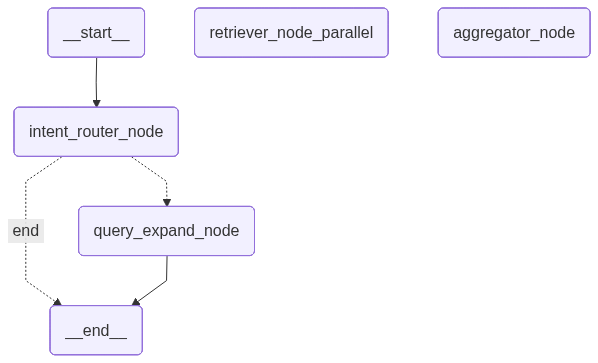

In [20]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
query = "Can I get a Tablet for my kid, a watch for me, a laptop for my wife and a waterproof speaker for our party next week?"
initial_state = {
    "initial_query": query
}

In [22]:
result = graph.invoke(initial_state)

In [24]:
result

{'expanded_query': ['Search for Tablet options for the specified user or family member',
  'Search for watch options for the specified user or family member',
  'Search for laptop options for the specified user or family member',
  'Search for waterproof speaker options for the specified user or family member'],
 'retrieved_context': [{'retrieved_context_ids': ['B09S6THZJ1',
    'B0BBM8MVW3',
    'B09QKNYJBL',
    'B07C3G57MG',
    'B003IZHG6K',
    'B073XD76GT',
    'B00JE5EP0S',
    'B07F4P3JH7',
    'B0B852M28H',
    'B00JQN5ZAM'],
   'retrieved_contexts': ["GrandPad Tablet for Seniors, Accessibility Enabled Tablet, 4G LTE, Bluetooth Enabled Tablet with Wireless Charger, Stylus - 1 Month Premium Service with 4G Included [] Computers ['MADE FOR SENIOR CITIZENS: The GrandPad is the ideal connectivity device for your loved ones who are aging, or have hearing & eyesight issues. A simple interface & easy-connectivity makes it the perfect choice for families looking to stay connected.', '

In [25]:
print(result.get("answer", []))

- Query: Search for Tablet options for the specified user or family member
  - Best option: GrandPad Tablet for Seniors
  - Why: Designed specifically for seniors with accessibility features and easy connectivity.
  - Price/Ratings: $399.0 / 4.1

- Query: Search for watch options for the specified user or family member
  - Best option: Kingstar Smart Watch
  - Why: Waterproof with fitness tracking features including heart rate and sleep monitoring.
  - Price/Ratings: $96.55 / 4.1

- Query: Search for laptop options for the specified user or family member
  - Best option: GrandPad Tablet for Seniors (not a traditional laptop but best match)
  - Why: Accessibility enabled and suitable for seniors, though not a traditional laptop.
  - Price/Ratings: $399.0 / 4.1

- Query: Search for waterproof speaker options for the specified user or family member
  - Best option: MEGUO Bluetooth Speaker with Bass+
  - Why: IPX7 waterproof rating, 24-hour playtime, and good sound quality.
  - Price/Ratin

### Agent Single Turn In

State and Pydantic Models for structured outputs

In [26]:
class RagGenerationResponse(BaseModel):
    answer: str = Field(description="The answer to the question")
    reasoning: str = Field(description="The reasoning behind the answer")

class RAGUsedContext(BaseModel):
    id: str | int = Field(description="The ID of the retrieved review")
    review: str = Field(description="The text of the retrieved review")
    title: str | None = Field(default=None, description="The product title")
    description: str | list[str] | None = Field(default=None, description="The product description")
    categories: list[str] = Field(default_factory=list, description="The product categories")
    images: list[dict] = Field(default_factory=list, description="The product image variants")
    videos: list[dict] = Field(default_factory=list, description="The product videos")
    features: list[str] = Field(default_factory=list, description="The product feature bullets")
    main_category: str | None = Field(default=None, description="The product main category")
    store: str | None = Field(default=None, description="The store or brand")
    price: float | None = Field(default=None, description="The product price")
    rating_number: int | None = Field(default=None, description="The product rating count")
    details: dict | None = Field(default=None, description="The product details map")

class RagGenerationResponseReference(BaseModel):
    answer: str = Field(description="The answer to the question")
    reasoning: str = Field(description="The reasoning behind the answer")
    used_context: list[RAGUsedContext] = Field(description="The list of retrieved reviews used to generate the answer")
    references: list[RAGUsedContext] = Field(description="The list of references used to generate the answer")

In [27]:
class ToolCall(BaseModel):
    tool_name: str = Field(description="The name of the tool to call")
    arguments: dict = Field(description="The arguments to pass to the tool")

In [28]:
class State(BaseModel):
    expanded_query: List[str] = Field(default_factory=list)
    messages: Annotated[List[Any], add] = Field(default_factory=list)
    retrieved_context: Annotated[List[dict], add] = Field(default_factory=list)
    initial_query: str = ""
    answer: str = ""
    question_relevant: bool = False
    available_tools: Annotated[List[dict], add] = Field(default_factory=list)
    final_answer: bool = False
    iteration: int = 0
    tool_calls: List[ToolCall] = Field(default_factory=list)
    references: Annotated[List[RAGUsedContext], add] = Field(default_factory=list)

### Tool Router Edge

In [29]:
def tool_router(state: State) -> str:
    """Decide whether to continue or end"""
    if state.final_answer:
        return "end"
    elif state.iteration > 2:
        return "end"
    elif len(state.tool_calls) > 0:
        return "tools"
    else:
        return "end"

### Graph

In [30]:
@traceable(
    name="intent_router_node",
    run_type="llm",
    tags=["routing", "openai"],
    metadata={"model": "gpt-4.1-mini", "ls-provider": "openai"}
)
def intent_router_node(state: State) -> dict:
    prompt_template = """You are an intent router for a shopping search assistant.
Determine if the user's question is relevant to shopping search and can be answered based on product information.
If the question is relevant, provide a concise answer. If not, politely decline to answer.

Instructions:
- Analyze the user's initial query and the conversation history to determine if the question is about shopping search and can be answered based on product information.
- If the question is relevant to shopping search, set question_relevant to true and provide a concise answer based on the conversation history and your knowledge.
- If the question is not relevant to shopping search, set question_relevant to false and provide a polite decline message in the answer, such as "I'm here to help with shopping-related questions. Could you please clarify your request or ask a question about products?".
- Do not attempt to answer questions that are not relevant to shopping search, even if you have some knowledge about the topic. Always prioritize relevance
- If the question is not relevant, return False in field "question_relevant" and set "answer" to explanation why it is not relevant.
- If the question is relevant, return True in field "question_relevant" and provide the answer in field "answer".
- You should only anser questions about the products in stock, If the question is not about the products in stock, you should ask for clarification instead of trying to answer it.
"""

    template = Template(prompt_template)
    prompt = template.render()

    messages = state.messages
    conversation = []
    for message in messages:
        conversation.append(convert_to_openai_messages(message))

    client = instructor.from_openai(OpenAI())

    response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=IntentRouterResponse,
        messages=[{"role": "system", "content": prompt}, *conversation],
        temperature=0.1,
    )

    if isinstance(response, (tuple, list)):
        response = response[0]

    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }


In [31]:
def intent_router_conditional_edges(state):
    if state.question_relevant:
        return "agent_node"
    else:
        return "end"

In [32]:
workflow = StateGraph(State)

tools = [get_formatted_context]
tool_node = ToolNode(tools)
tool_descriptions = get_tool_descriptions(tools)

workflow.add_node("agent_node", agent_node)
workflow.add_node("tool_node", tool_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")

workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "agent_node": "agent_node",
        "end": END,
    },
)

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END,
    },
)

workflow.add_edge("tool_node", "agent_node")

graph = workflow.compile()

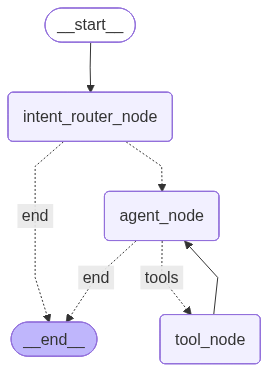

In [33]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
initial_state = {
    "messages": [{
        "role": "user",
        "content": "Can I get a Tablet for my kid, a watch for me, a laptop for my wife and a waterproof speaker for our party next week?"
    }],
    "available_tools": tool_descriptions
}

In [35]:
result = graph.invoke(initial_state)

AttributeError: 'State' object has no attribute 'messages'

In [ ]:
result

{'expanded_query': ['Search for Tablet options for the specified user or family member',
  'Search for watch options for the specified user or family member',
  'Search for laptop options for the specified user or family member',
  'Search for waterproof speaker options for the specified user or family member'],
 'retrieved_context': [{'retrieved_context_ids': ['B09S6THZJ1',
    'B09QKNYJBL',
    'B0BBM8MVW3',
    'B003IZHG6K',
    'B07C3G57MG',
    'B073XD76GT',
    'B07F4P3JH7',
    'B00JE5EP0S',
    'B0B852M28H',
    'B098ZFMY25'],
   'retrieved_contexts': ["GrandPad Tablet for Seniors, Accessibility Enabled Tablet, 4G LTE, Bluetooth Enabled Tablet with Wireless Charger, Stylus - 1 Month Premium Service with 4G Included [] Computers ['MADE FOR SENIOR CITIZENS: The GrandPad is the ideal connectivity device for your loved ones who are aging, or have hearing & eyesight issues. A simple interface & easy-connectivity makes it the perfect choice for families looking to stay connected.', '